# 03 - Machine-Learning Baselines

Train and evaluate the naive, linear/ridge, and tree-based baseline models via `src.ai.baselines` and `src.ai.evaluation`, using the fixed dataset splits from `src.ai.splitting`.


**Status:** placeholder created in Stage 1 (project scaffold). Populated in Stage 5 (baseline ML models).

This notebook is intentionally thin: it should only call reusable functions from `src/`, never contain modelling logic itself (PROJECT_BRIEF.md §25, §1.6).


In [1]:
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- hard-syncing to origin/{BRANCH}...")
        # Hard sync (fetch + reset --hard), not `git pull`: a plain pull can leave
        # a Colab VM's reused (not freshly cloned) checkout on stale tracked files
        # if the local branch has drifted or a merge doesn't fast-forward cleanly --
        # this bit twice (stale `src/` imports surviving a "fresh" notebook run on a
        # reconnected-but-not-recreated Colab runtime). Fetch+reset always makes the
        # tracked files exactly match origin/BRANCH; it never touches untracked/
        # gitignored files (e.g. the cached weather downloads), so nothing is lost.
        subprocess.run(["git", "fetch", "origin", BRANCH], check=True, cwd=str(repo_root))
        subprocess.run(["git", "reset", "--hard", f"origin/{BRANCH}"], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Defensive: evict any already-imported src.* modules from Python's module
# cache. The git sync above only fixes what's on *disk* -- if this cell runs
# in a kernel/runtime that already imported an old version of e.g.
# src.ai.neural_network earlier in the session (Colab can silently reconnect
# you to an already-running backend instead of starting a fresh one, even
# after fully closing and reopening the browser tab), Python's import system
# would keep serving that stale cached module object and ignore the sync
# entirely. Deleting the cache entries forces every subsequent `from src...
# import ...` below to re-read the just-synced file.
for _mod_name in list(sys.modules):
    if _mod_name == "src" or _mod_name.startswith("src."):
        del sys.modules[_mod_name]


In [2]:
import time
import pandas as pd

from src.config import load_site_config
from src.data.weather import get_processed_weather
from src.ai.features import build_feature_matrix
from src.ai.splitting import split_experiment_a
from src.ai.baselines import fit_linear_baseline, fit_naive_baseline, fit_tree_baseline
from src.ai.evaluation import compute_accuracy_metrics, compute_operational_metrics
from src.visualization.plotting import (
    plot_cross_model_metric_comparison, plot_over_under_prediction_rates,
    plot_predicted_vs_reference, plot_residual_distribution, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
site_config = load_site_config("jinan")

## Load the pilot scenario dataset and restrict to feasible scenarios

The target label (`optimal_capacity_kwh`) only exists for scenarios the mechanistic search found feasible (Stage 4: 56/100). Infeasible scenarios have no real capacity value to regress against -- they are excluded here, not imputed with a placeholder.

In [3]:
scenarios = pd.read_csv(PROJECT_ROOT / "data" / "scenarios" / "pilot_scenarios.csv")
feasible = scenarios[scenarios["feasible"]].reset_index(drop=True)
print(f"{len(feasible)}/{len(scenarios)} scenarios are feasible and usable for regression.")

56/100 scenarios are feasible and usable for regression.


## Feature engineering

Regenerates each scenario's hourly load/PV/wind series from its stored inputs (deterministic given the same random seed) and computes load, generation, and net-load features (PROJECT_BRIEF.md §15). No leakage columns (`src.ai.features.LEAKAGE_COLUMNS`).

In [4]:
weather = get_processed_weather("jinan", 2023)
t0 = time.perf_counter()
features = build_feature_matrix(feasible, weather, site_config)
feature_engineering_seconds = time.perf_counter() - t0
print(f"Feature engineering: {feature_engineering_seconds:.1f}s for {len(features)} scenarios, "
      f"{features.shape[1] - 1} features.")

merged = features.merge(feasible[["scenario_id", "optimal_capacity_kwh"]], on="scenario_id")
feature_columns = [c for c in features.columns if c != "scenario_id"]
merged.to_csv(TABLES_DIR / "scenario_engineered_features.csv", index=False)
features.head()

Feature engineering: 3.0s for 56 scenarios, 37 features.


,scenario_id,annual_load_kwh,peak_load_kw,mean_load_kw,std_load_kw,load_factor,peak_to_average_ratio,daytime_load_share,nighttime_load_share,seasonal_load_variability,...,max_cumulative_deficit_event_kwh,n_deficit_hours,n_surplus_hours,net_load_q10_kw,net_load_q50_kw,net_load_q90_kw,worst_monthly_renewable_to_load_ratio,reliability_target_load_served,round_trip_efficiency,usable_soc_window_fraction
0,1,28015.437516,7.006534,3.198109,1.285374,0.456447,2.190836,0.600835,0.399165,0.113406,...,122.377967,5150,3610,-15.180545,1.060209,4.346251,1.336858,0.998341,0.937948,0.864552
1,6,10294.490790,2.622676,1.175170,0.472852,0.448081,2.231742,0.601667,0.398333,0.111641,...,35.272661,4298,4462,-7.380353,-0.055298,1.505721,2.004529,0.995984,0.943465,0.856146
2,7,15591.879925,4.031469,1.779895,0.718805,0.441500,2.265004,0.601349,0.398651,0.113801,...,49.860793,4135,4625,-12.727188,-0.319686,2.246748,2.242817,0.996016,0.922399,0.813047
3,8,32143.176026,8.181620,3.669312,1.472492,0.448482,2.229742,0.602163,0.397837,0.112514,...,125.105104,4860,3900,-15.765938,0.806581,4.886067,1.403689,0.992736,0.882774,0.787343
4,11,25240.849044,6.226819,2.881375,1.159651,0.462736,2.161058,0.601714,0.398286,0.111949,...,97.377280,4725,4035,-14.940818,0.505764,3.822499,1.592446,0.995673,0.912563,0.717530


## Dataset split (Experiment A: grouped 70/15/15)

See `src.ai.splitting`'s docstring: with only 56 i.i.d.-sampled feasible scenarios (no natural scenario families), grouping by `scenario_id` is equivalent to -- and exactly as valid as -- a plain random split.

In [5]:
ml_cfg_seed = 42
splits = split_experiment_a(merged, group_column="scenario_id", random_seed=ml_cfg_seed)
print({k: len(v) for k, v in splits.items()})

split_labels = pd.Series(index=merged.index, dtype=str)
for name, idx in splits.items():
    split_labels.loc[idx] = name
merged["split"] = split_labels
merged[["scenario_id", "split"]].to_csv(TABLES_DIR / "dataset_split_assignments.csv", index=False)

X_train, y_train = merged.loc[splits["train"], feature_columns], merged.loc[splits["train"], "optimal_capacity_kwh"]
X_val, y_val = merged.loc[splits["val"], feature_columns], merged.loc[splits["val"], "optimal_capacity_kwh"]
X_test, y_test = merged.loc[splits["test"], feature_columns], merged.loc[splits["test"], "optimal_capacity_kwh"]

{'train': 39, 'val': 8, 'test': 9}


## Train the three baselines

Naive (training-median `DummyRegressor`), Ridge (alpha selected on the validation split), Random Forest (n_estimators/max_depth selected on the validation split). Hyperparameter selection never touches the test split.

In [6]:
ml_cfg = {
    "alpha_grid": [0.01, 0.1, 1.0, 10.0],
    "n_estimators_grid": [100, 300],
    "max_depth_grid": [3, 5, None],
}

train_times = {}
t0 = time.perf_counter(); naive_model = fit_naive_baseline(X_train, y_train); train_times["naive"] = time.perf_counter() - t0
t0 = time.perf_counter(); ridge_model = fit_linear_baseline(X_train, y_train, X_val, y_val, ml_cfg["alpha_grid"]); train_times["ridge"] = time.perf_counter() - t0
t0 = time.perf_counter(); rf_model = fit_tree_baseline(X_train, y_train, X_val, y_val, ml_cfg["n_estimators_grid"], ml_cfg["max_depth_grid"]); train_times["random_forest"] = time.perf_counter() - t0

models = {"naive": naive_model, "ridge": ridge_model, "random_forest": rf_model}
train_times

{'naive': 0.0010209870000608134,
 'ridge': 0.01539728299997023,
 'random_forest': 1.132101648999992}

## Evaluate on the held-out test split

In [7]:
accuracy_by_model = {}
operational_by_model = {}
predictions_by_model = {}

for name, model in models.items():
    pred = model.predict(X_test)
    predictions_by_model[name] = pred
    accuracy_by_model[name] = compute_accuracy_metrics(y_test, pred)
    operational_by_model[name] = compute_operational_metrics(y_test, pred)

accuracy_table = pd.DataFrame(accuracy_by_model).T
operational_table = pd.DataFrame(operational_by_model).T
accuracy_table.to_csv(TABLES_DIR / "accuracy_metrics_by_model.csv")
operational_table.to_csv(TABLES_DIR / "reliability_metrics_by_model.csv")
accuracy_table

,mae,rmse,r2,median_absolute_error,mape,max_absolute_error,mean_signed_error_bias,pct_within_5pct,pct_within_10pct,pct_within_20pct,n_samples
naive,131.413333,158.389333,-2.209016,138.240000,0.518250,307.200000,-131.413333,0.000000,0.000000,0.111111,9.0
ridge,76.491506,92.864341,-0.103108,54.291438,0.344838,170.196321,-8.241455,0.111111,0.111111,0.111111,9.0
random_forest,58.019685,86.528887,0.042272,37.189207,0.221067,223.938301,-33.851328,0.111111,0.333333,0.555556,9.0


In [8]:
operational_table

,underprediction_rate,overprediction_rate,exact_match_rate,mean_underprediction_kwh,max_underprediction_kwh,mean_overprediction_kwh,max_overprediction_kwh
naive,1.000000,0.000000,0.0,131.413333,307.200000,0.000000,0.000000
ridge,0.555556,0.444444,0.0,76.259665,158.605400,76.781307,170.196321
random_forest,0.444444,0.555556,0.0,103.354890,223.938301,21.751521,45.635110


**Read this honestly, not optimistically:** the test split has only 9 scenarios (15% of 56 feasible ones). Metrics computed on 9 points -- especially R^2 -- are extremely noisy and should not be over-interpreted as a reliable performance estimate. This is a real limitation of the 100-scenario pilot, not something to paper over; the negative/near-zero R^2 values seen here are an expected consequence of a small,  high-dimensional (37-feature) regression problem with ~39 training rows, not evidence the pipeline is broken.

## Runtime comparison (baseline ML vs. mechanistic search)

In [9]:
mechanistic_runtime_per_scenario = scenarios["mechanistic_optimization_runtime_seconds"].mean()
inference_start = time.perf_counter()
for name, model in models.items():
    model.predict(X_test)
inference_seconds_for_all_models_all_test_rows = time.perf_counter() - inference_start
inference_seconds_per_prediction = inference_seconds_for_all_models_all_test_rows / (len(models) * len(X_test))

print(f"Mechanistic search: {mechanistic_runtime_per_scenario:.3f}s/scenario (31-candidate exhaustive search)")
print(f"Feature engineering: {feature_engineering_seconds / len(features):.3f}s/scenario")
print(f"Baseline training time: {train_times}")
print(f"Baseline inference: {inference_seconds_per_prediction * 1000:.3f}ms/prediction (negligible vs. mechanistic search)")

runtime_table = pd.DataFrame({
    "stage": ["mechanistic_search_per_scenario", "feature_engineering_per_scenario",
               "naive_train", "ridge_train", "random_forest_train", "inference_per_prediction"],
    "seconds": [mechanistic_runtime_per_scenario, feature_engineering_seconds / len(features),
                train_times["naive"], train_times["ridge"], train_times["random_forest"],
                inference_seconds_per_prediction],
})
runtime_table.to_csv(TABLES_DIR / "runtime_comparison_stage5.csv", index=False)
runtime_table

Mechanistic search: 1.240s/scenario (31-candidate exhaustive search)
Feature engineering: 0.054s/scenario
Baseline training time: {'naive': 0.0010209870000608134, 'ridge': 0.01539728299997023, 'random_forest': 1.132101648999992}
Baseline inference: 0.931ms/prediction (negligible vs. mechanistic search)


,stage,seconds
0,mechanistic_search_per_scenario,1.240066
1,feature_engineering_per_scenario,0.054054
2,naive_train,0.001021
3,ridge_train,0.015397
4,random_forest_train,1.132102
5,inference_per_prediction,0.000931


## Required figures (PROJECT_BRIEF.md §27, AI-comparison figures 17, 18, 21, 23)

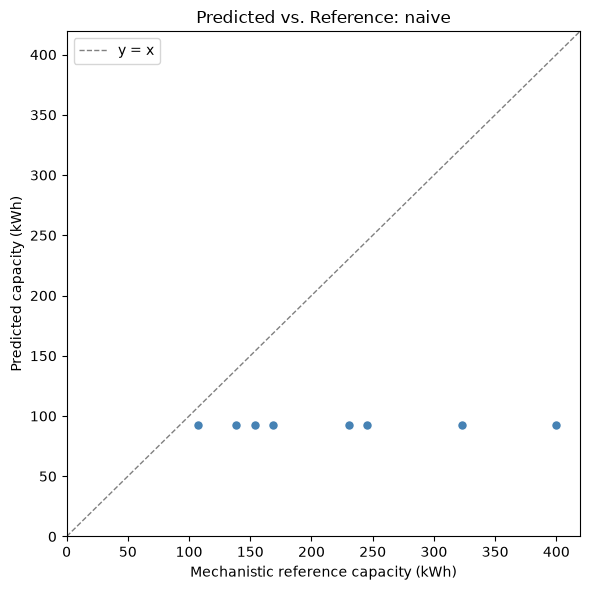

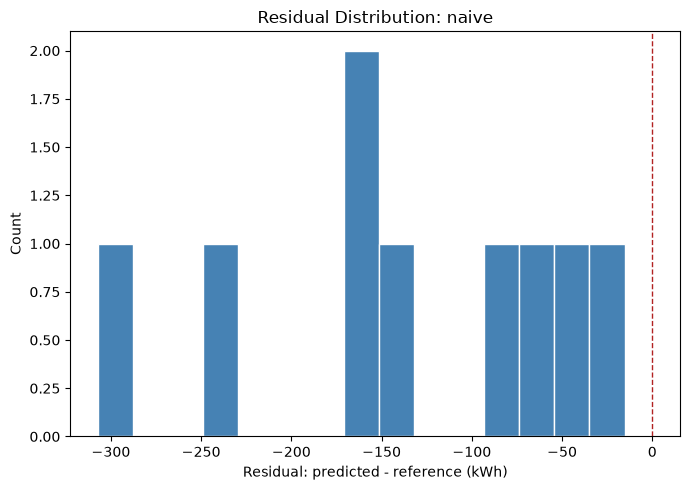

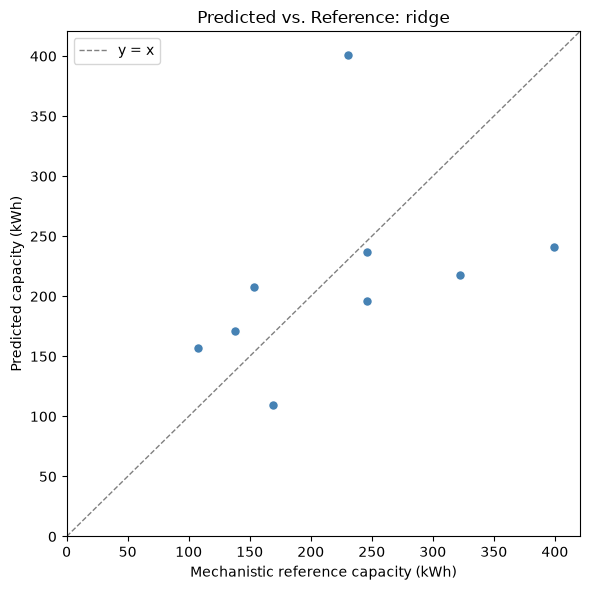

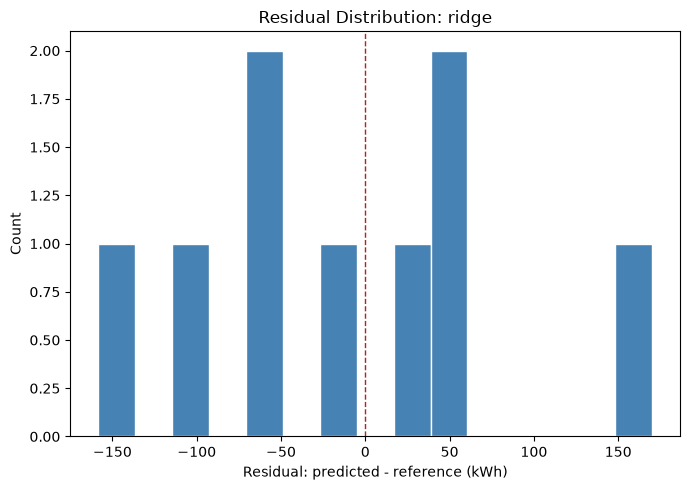

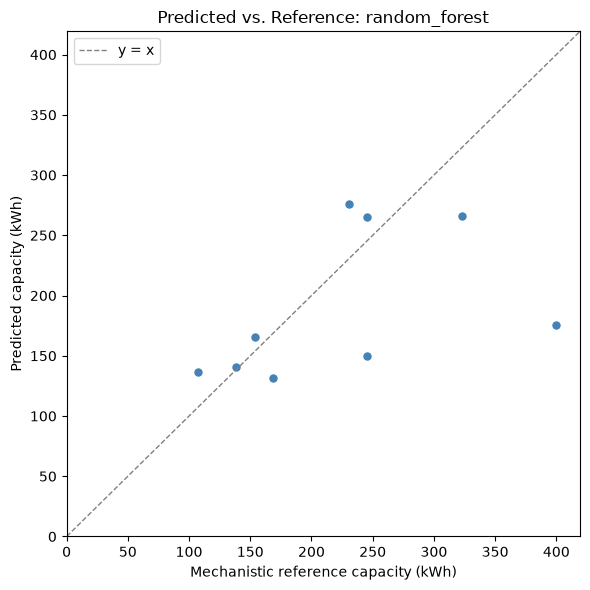

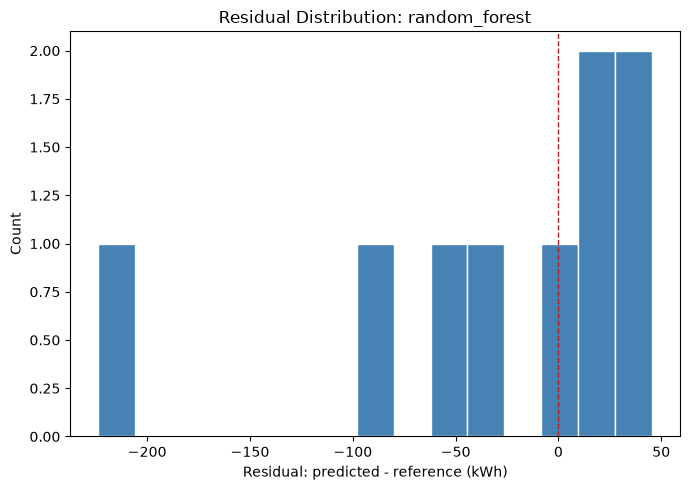

In [10]:
for name, pred in predictions_by_model.items():
    save_figure(plot_predicted_vs_reference(y_test, pred, name), FIGURES_DIR / f"17_predicted_vs_reference_{name}.png")
    save_figure(plot_residual_distribution(y_test, pred, name), FIGURES_DIR / f"18_residuals_{name}.png")

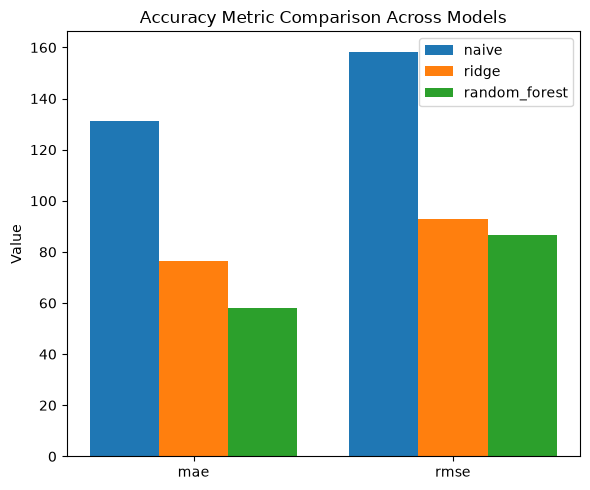

In [11]:
fig = plot_cross_model_metric_comparison(accuracy_by_model, ["mae", "rmse"])
save_figure(fig, FIGURES_DIR / "21_metric_comparison.png")

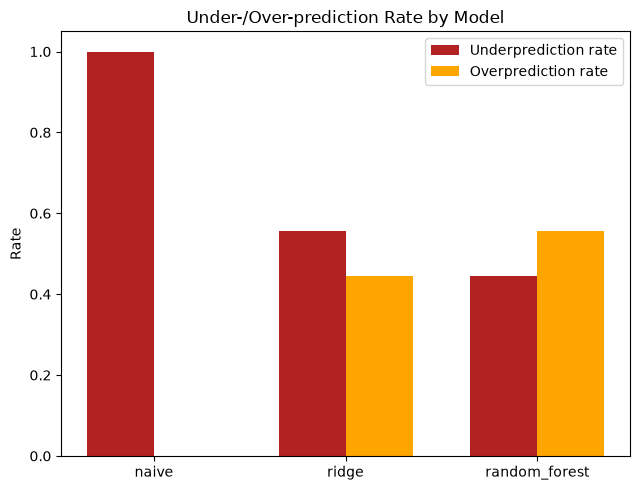

In [12]:
fig = plot_over_under_prediction_rates(operational_by_model)
save_figure(fig, FIGURES_DIR / "23_over_under_prediction.png")

## Stage 5 summary

- Trained naive (median), Ridge, and Random Forest baselines on the 56 feasible pilot scenarios (39 train / 8 val / 9 test), with hyperparameter selection restricted to train+val, never the test split.
- Test-set accuracy is genuinely weak in absolute terms (R^2 near zero for most models) -- an honest consequence of a 39-row training set with 37 engineered features, not a bug. Random Forest beats Ridge beats the naive baseline on MAE, which at least confirms the features carry real signal even at this tiny scale.
- Underprediction/overprediction rates are reported separately per model (never folded into a blended accuracy number), per PROJECT_BRIEF.md §21.
- Mechanistic search remains ~1.2s/scenario; ML inference is effectively instantaneous (sub-millisecond) once trained -- the real break-even question (PROJECT_BRIEF.md §22) is deferred to Stage 9's full comparison, once the neural network (Stage 6) and physical verification (Stage 7) exist too.

**Not yet done:** the neural network (Stage 6) and the mandatory physical (mechanistic) verification of any AI prediction (Stage 7) -- accuracy metrics alone, as shown here, are explicitly NOT sufficient per PROJECT_BRIEF.md §20 to judge whether a predicted battery size is usable.